# Mini-proyecto de Computer Vision (OpenCV): *lectura didáctica* de una matrícula UK (amarilla) sin OCR

> **Objetivo didáctico**: construir un pipeline que combine varias técnicas clásicas de CV, **sin pretender ser perfecto**, para:
1. Cargar una imagen (local o URL) con la **parte trasera de un coche** y una **matrícula UK amarilla**.
2. **Normalizar** valores (0–1) y **redimensionar** la imagen.
3. Usar **K-Means** sobre píxeles para quedarnos con la región **amarilla** (matrícula + ruido).
4. **Binarizar** y aplicar **morfología** (erode/dilate) para limpiar.
5. Localizar la **caja de la matrícula** con **proyecciones** (sumas por fila/columna).
6. Segmentar cada **carácter** con la misma idea (proyección vertical).
7. Reconocer cada carácter por **comparación con plantillas** (*template matching*).
8. Devolver la predicción final.

---

## ⚠️ Aviso importante (ético y práctico)
- Usa imágenes **propias** o con derechos adecuados (o datasets educativos).
- Este notebook es **para aprender** técnicas, no para desplegar un sistema robusto en producción.

---

## Requisitos
- `opencv-python`
- `numpy`
- `matplotlib`
- (opcional) `requests` para cargar desde URL

In [351]:
# Si estás en Colab / entorno limpio:
# !pip -q install opencv-python matplotlib requests

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Opcional para URLs
import requests
from io import BytesIO

## 1. Cargar una imagen (local o URL) con la **parte trasera de un coche** y una **matrícula UK amarilla**.

In [352]:
# --- Configuración de entrada ---
USE_URL = True

# URL por defecto (Wikimedia Commons). Si falla, pon USE_URL=False y usa ruta local.
IMAGE_URL = "https://cdn.warrantywise.co.uk/wp-content/uploads/2020/09/03115906/The-New-70-Plate-Registration-Has-Launched-Cover-Photo.jpg.webp"
LOCAL_PATH = None

In [353]:
def load_image_bgr(use_url=True, image_url=None, local_path=None):
    """Carga una imagen en BGR (formato OpenCV), desde URL o disco."""
    if use_url:

        if not image_url:
            raise ValueError("Falta IMAGE_URL")
        
        r = requests.get(image_url, timeout=30)
        r.raise_for_status()
        img_arr = np.frombuffer(r.content, dtype=np.uint8)
        img = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)

        if img is None:
            raise ValueError("No se pudo decodificar la imagen desde URL.")
        
        return img
    
    else:

        if not local_path:
            raise ValueError("Falta LOCAL_PATH")
        
        img = cv2.imread(local_path, cv2.IMREAD_COLOR)

        if img is None:
            raise ValueError(f"No se pudo leer la imagen: {local_path}")
        
        return img

img_bgr = load_image_bgr(USE_URL, IMAGE_URL, LOCAL_PATH)

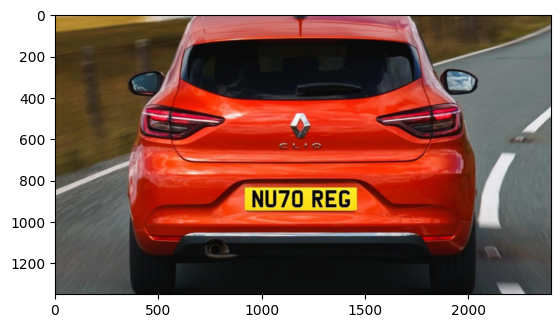

In [354]:
# image display
plt.imshow(img_bgr[:, :, [2, 1, 0]])

## 2. **Normalizar** valores (0–1) y **redimensionar** la imagen.

In [355]:
# change the color to RGB (so the yellow appears as it is)
img_bgr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# reshape to a list of pixels (M, 3) 3->channels
pixel_vals = img_bgr.reshape((-1,3))

## 3. Usar **K-Means** sobre píxeles para quedarnos con la región **amarilla** (matrícula + ruido).

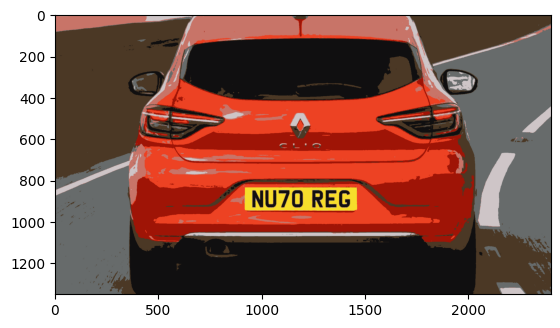

In [356]:
# convert to float32 for the kmeans
pixel_vals = np.float32(pixel_vals)

# stops the algorithm when the given accuracy or iteration is reached
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)

k = 8

# apply the k-means
retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# convert back to uint8
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((img_bgr.shape[0], img_bgr.shape[1], img_bgr.shape[2]))

plt.imshow(segmented_image)

Cluster 1: RGB = [237  66  35]
Cluster 2: RGB = [16 15 16]
Cluster 3: RGB = [75 56 37]
Cluster 4: RGB = [103 107 107]
Cluster 5: RGB = [246 222  43]
Cluster 6: RGB = [206 197 199]
Cluster 7: RGB = [159  20   6]
Cluster 8: RGB = [200 116 104]


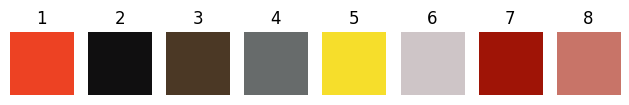

In [357]:
# transform into 1D array
labels = labels.flatten()

# numbers of the color clusters &
# visualization to ensure the cluster prediction below is correct
for i, cluster in enumerate(centers):
    print(f"Cluster {i+1}: RGB = {cluster}")
 
    plt.subplot(1, k, i+1)
    plt.axis('off')
    plt.imshow([[cluster / 255]])
    plt.title(f'{i+1}')

plt.tight_layout()
plt.show()

In [358]:
yellow = [250, 250, 20]

# euclidean distance squared to see which cluster is closer to yellow
dist = np.sqrt(np.sum((centers - yellow) ** 2, axis=1))

# index of the closest cluster (yellow)
smallest_distance = np.where(dist==np.amin(dist))
yellow_cluster_idx = np.argmin(dist)

print(f"Nearest cluster similar to yellow is the {yellow_cluster_idx + 1} with RGB = {centers[smallest_distance]}")

Nearest cluster similar to yellow is the 5 with RGB = [[246 222  43]]


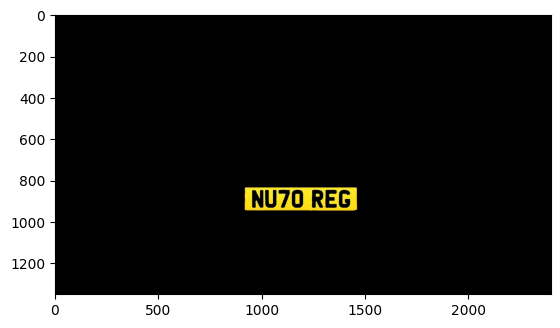

In [359]:
# binary mask for the yellow cluster
mask = (labels == yellow_cluster_idx).astype(np.uint8) * 255

# reshape to original image dimensions (height, width)
mask = mask.reshape(img_bgr.shape[:2])

# apply the mask to the original image
res = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)

plt.imshow(res)

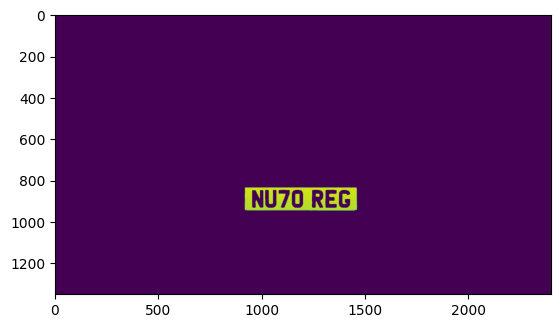

In [360]:
# convert to grayscale for better visualization of the masked area
res = cv2.cvtColor(res, cv2.COLOR_RGB2GRAY)

plt.imshow(res)

## 4. **Binarizar** y aplicar **morfología** (erode/dilate) para limpiar. Y 5. Localizar la **caja de la matrícula** con **proyecciones** (sumas por fila/columna).

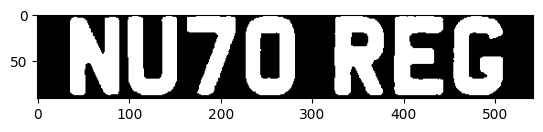

In [361]:
# 4. binary thresholding, values greater than 0 are replaced with 255 (white) and others with 0 (black)
line, thresh = cv2.threshold(res, 0, 255, cv2.THRESH_BINARY)

m = (thresh > 0).astype(int)

# 5. with the mask we add the white pixels in order to find the plate

# sum horizontally the white pixels in each row
sumas_filas = np.sum(m, axis=1)
# ignore rows with less than 20% of the maximum white pixel count
umbral_y = np.max(sumas_filas) * 0.20
filas_validas = np.where(sumas_filas > umbral_y)[0]

# keep the first and last valid rows
y0, y1 = filas_validas[0], filas_validas[-1] 

# crop the binary mask to the valid rows
m_recortada_horizontal = m[y0:y1, :]

# same thing, but vertically
sumas_columnas = np.sum(m_recortada_horizontal, axis=0)
umbral_x = np.max(sumas_columnas) * 0.20
cols_validas = np.where(sumas_columnas > umbral_x)[0]

x0, x1 = cols_validas[0], cols_validas[-1]

matricula_recortada = thresh[y0 + 10:y1 - 10, x0:x1]

# invert the colors
matricula_recortada = 255 - matricula_recortada

plt.imshow(matricula_recortada, cmap='gray')

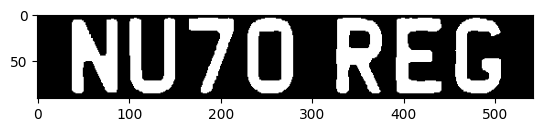

In [362]:
# 4. 5x5 kernel for morphological operations
kernel = np.ones((5, 5), np.uint8)

# erode to remove small noise and separate characters
erode = cv2.erode(matricula_recortada, kernel, iterations=1)

plt.imshow(erode, cmap='gray') 

## 6. Segmentar cada **carácter** con la misma idea (proyección vertical).

Text(0.5, 1.0, 'Vertical histogram of the plate.')

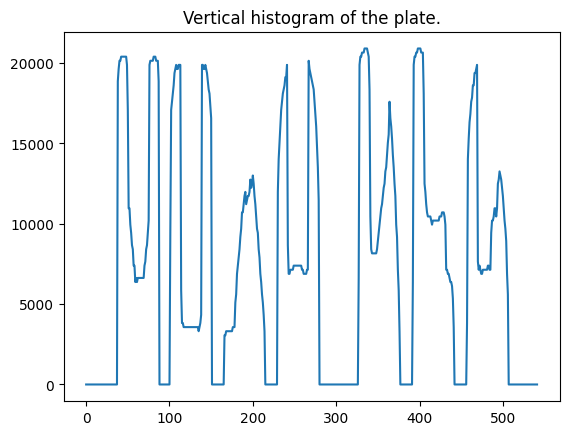

In [363]:
# vertically sum the pixel values for the histogram
vertical_sum = np.sum(erode, axis=0)

plt.plot(vertical_sum)

plt.title("Vertical histogram of the plate.")

In [364]:
# list to store the start and end positions
character_positions = []
# list to store the extracted character images
char_arr = []
start = None # flag

# iterate through the vertical histogram to find character boundaries
for i, sum_val in enumerate(vertical_sum):
    # start of character
    if sum_val > 0 and start is None:
        start = i
        
    # end of character
    elif sum_val == 0 and start is not None:
        character_positions.append((start, i))
        start = None

# extract and save each character based on the identified positions
for i, (start, end) in enumerate(character_positions):
    char = erode[:, start:end]
    cv2.imwrite(f'char_{i}.png', 255 - char)
    char_arr.append(char.copy())

## 7. Reconocer cada carácter por **comparación con plantillas** (*template matching*). Y 8. Devolver la predicción final.

In [365]:
TEMPLATE_H = 45
TEMPLATE_W = 33

ALPHABET = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

def make_template(char, w=TEMPLATE_W, h=TEMPLATE_H):
    img = np.zeros((h, w), dtype=np.uint8)
    # Fuente Hershey; probamos una combinación que suele verse "placa"
    font = cv2.FONT_HERSHEY_SIMPLEX  
    scale = 1.8
    thickness = 5

    # Centramos el texto
    (tw, th), baseline = cv2.getTextSize(char, font, scale, thickness)
    x = 2+(w - tw) // 2
    y = -2 + (h + th) // 2
    cv2.putText(img, char, (x, y), font, scale, 255, thickness, cv2.LINE_AA)

    # Opcional: pequeña dilatación para engordar un pelín
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (2,2))
    img = cv2.dilate(img, k, iterations=1)

    return img

templates = {ch: make_template(ch) for ch in ALPHABET}


In [366]:
prediction = ""

# each character compare against all templates to find the best match
for i, char_img in enumerate(char_arr):
    
    # resize the image to match the template size (33x45)
    char_resized = cv2.resize(char_img, (TEMPLATE_W, TEMPLATE_H))
    char_resized = char_resized.astype(np.uint8)
    
    best_letter = "?"
    best_score = -1
    
    # compare with each template
    for letra_plantilla, img_plantilla in templates.items():
        
        # matchTemplate compares images and gives a similarity score
        resultado = cv2.matchTemplate(char_resized, img_plantilla, cv2.TM_CCOEFF_NORMED)
        
        # returns the best match value (similarity score -1.0 - 1.0)
        _, max_val, _, _ = cv2.minMaxLoc(resultado)
        
        # save the best letter
        if max_val > best_score:
            best_score = max_val
            best_letter = letra_plantilla
            
    # best matching letter for this character
    prediction += best_letter
    print(f"Letter {i}: Seems similar to the '{best_letter}' (Confidence: {round(best_score*100, 1)}%)")

print(f"\nFinal prediction: {prediction}")


Letter 0: Seems similar to the 'N' (Confidence: 83.9%)
Letter 1: Seems similar to the 'U' (Confidence: 87.8%)
Letter 2: Seems similar to the '7' (Confidence: 80.0%)
Letter 3: Seems similar to the '0' (Confidence: 76.1%)
Letter 4: Seems similar to the 'R' (Confidence: 72.8%)
Letter 5: Seems similar to the 'E' (Confidence: 54.3%)
Letter 6: Seems similar to the 'G' (Confidence: 72.4%)

Final prediction: NU70REG


## 9. Bibliografía

kmeans: https://docs.opencv.org/4.x/d1/d5c/tutorial_py_kmeans_opencv.html 

best color cluster: https://stackoverflow.com/questions/54242194/find-the-closest-color-to-a-color-from-given-list-of-colors

appliance of masks: https://pytutorial.com/python-opencv-cv2bitwise_and-guide/

image binarization: https://note.nkmk.me/en/python-numpy-opencv-image-binarization/ 

eroding: https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html

template matching: https://www.geeksforgeeks.org/python/template-matching-using-opencv-in-python/

note: for the localization of the plate we had to use a little bit of `Chati` because we didn´t find any resources.